In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [261]:
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "AVGO", "META", "TSLA", "BRK-B", "JPM"]
data = yf.download(tickers, start='2015-10-30', end='2025-10-30', interval='1d', auto_adjust = True)
prices = data["Close"]

[*********************100%***********************]  10 of 10 completed


In [262]:
def momentum(prices, lookback=90, holding=30, top_n=3) :
    return_lookback = prices.pct_change(lookback)
    
    portfolio_value = []
    dates = []
    holdings = []

    start = lookback
    for i in range(start, len(prices), holding) :
        momentum = return_lookback.iloc[i]
        current_date = prices.index[i]
        dates.append(current_date)

        top_tickers = momentum.nlargest(top_n).index.tolist()
        holdings.append(top_tickers)
        
        if i + holding < len(prices) :
            buy_price = prices.loc[current_date, top_tickers]
            sell_price = prices.iloc[i + holding][top_tickers]
            period_return = ((sell_price / buy_price) - 1).mean()
            portfolio_value.append(period_return)

        else :
            break
    dates.pop()
    portfolio_cumulative = (1 + pd.Series(portfolio_value)).cumprod()
    return pd.Series(portfolio_cumulative.values, index = dates), holdings


def buy_hold(prices) :
    returns = prices.pct_change().mean(axis=1)
    cumulative = (1 + returns).cumprod()
    return cumulative

In [263]:
momentum_portfolio, holdings = momentum(prices, lookback=90, holding=30, top_n=3)
benchmark = buy_hold(prices)
print(f"\n✅ Backtest terminé")
print(f"Performance Momentum: {(momentum_portfolio.iloc[-1] - 1) * 100:.2f}%")
print(f"Performance Buy & Hold: {(benchmark.iloc[-1] - 1) * 100 :.2f}%")


✅ Backtest terminé
Performance Momentum: 4034.50%
Performance Buy & Hold: 1968.12%


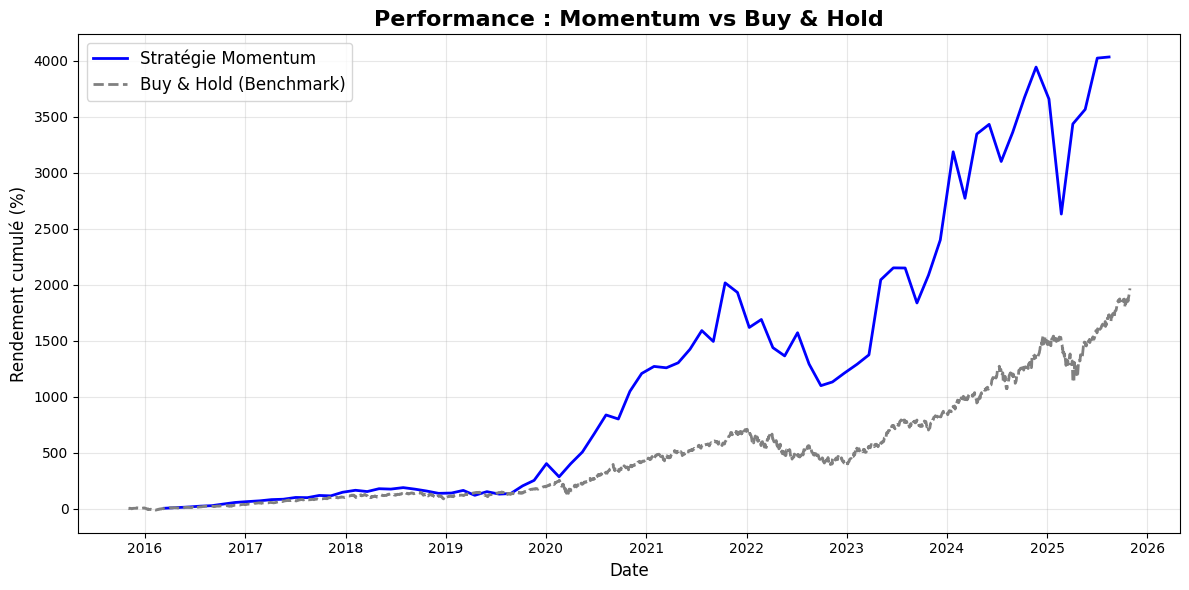

In [264]:
plt.figure(figsize=(12, 6))
plt.plot(momentum_portfolio.index, (momentum_portfolio - 1) * 100, label='Stratégie Momentum', linewidth=2, color='blue')
plt.plot(benchmark.index, (benchmark - 1) * 100, label='Buy & Hold (Benchmark)', linewidth=2, color='gray', linestyle='--')
plt.title('Performance : Momentum vs Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rendement cumulé (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()